In [1]:
import pandas as pd

## 1. Chargement des données

Importation du dataset `dataset_wine.csv` et affichage des premières lignes pour comprendre la structure des données.

In [2]:
wine = pd.read_csv("dataset_wine.csv")
wine.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Description des variables

Le dataset contient **11 variables physico-chimiques** (features) et **1 variable cible** (`quality`).

| Variable | Unité | Description |
|---|---|---|
| `fixed acidity` | g/L | Concentration en acides fixes (principalement acide tartrique). Contrairement aux acides volatils, ces acides ne s'évaporent pas. |
| `volatile acidity` | g/L | Concentration en acide acétique (vinaigre). Un taux trop élevé donne un goût et une odeur de vinaigre désagréables. |
| `citric acid` | g/L | Concentration en acide citrique. Il apporte de la fraîcheur et de la complexité au goût. |
| `residual sugar` | g/L | Quantité de sucre restant après la fermentation. Plus ce taux est élevé, plus le vin est doux. |
| `chlorides` | g/L | Concentration en sel (chlorure de sodium). Un taux élevé donne un goût salé et désagréable. |
| `free sulfur dioxide` | mg/L | Fraction active du SO₂ libre — directement disponible pour protéger le vin contre l'oxydation. Indétectable en dessous de 50 mg/L. |
| `total sulfur dioxide` | mg/L | Quantité totale de SO₂ (libre + lié). Conservateur naturel, mais détectable en excès. |
| `density` | g/mL | Masse volumique du vin (≈ 1.0 g/mL). Diminue avec l'alcool, augmente avec le sucre résiduel. |
| `pH` | — | Acidité globale (0–14). Les vins rouges se situent typiquement entre 3.0 et 3.5. |
| `sulphates` | g/L | Concentration en K₂SO₄ — additif antimicrobien et antioxydant. |
| `alcohol` | % vol. | Pourcentage d'alcool. Résultat de la fermentation des sucres par les levures. |
| `quality` | score | Variable cible : note de qualité du vin (entier entre 3 et 8). |

## 3. Analyse exploratoire

### 3.1 Types de variables

Vérification des types pour s'assurer que toutes les features sont bien numériques (float64) et que la cible est entière (int64).

In [3]:
wine.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

### 3.2 Valeurs manquantes

Vérification de l'absence de valeurs manquantes. **Résultat : 0 valeur manquante** — le dataset est complet, aucun traitement d'imputation n'est nécessaire.

In [4]:
wine.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### 3.3 Distribution des classes (variable cible)

⚠️ **Déséquilibre des classes** — Les classes de qualité 5 et 6 sont très majoritaires, tandis que les classes 3, 4 et 8 sont sous-représentées. Ce déséquilibre est un problème majeur qui biaiserait les métriques d'évaluation et les prédictions du modèle.

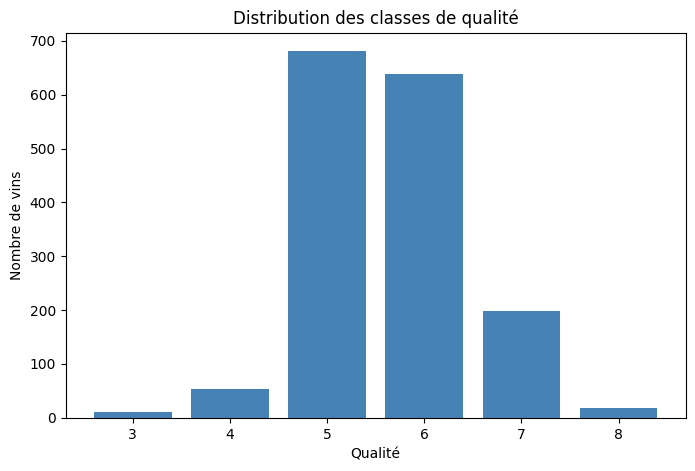

In [3]:
import matplotlib.pyplot as plt

# Calcul des counts et pourcentages
counts = wine['quality'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
plt.title('Distribution des classes de qualité')
plt.xlabel('Qualité')
plt.ylabel('Nombre de vins')
plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modèle de référence (données brutes déséquilibrées)

Avant tout rééquilibrage, on entraîne un `RandomForestClassifier` sur les données originales avec une validation croisée **StratifiedKFold** (5 folds). Le StratifiedKFold garantit que chaque fold respecte la distribution des classes originales.

> **Objectif :** Évaluer les performances du modèle sur les données déséquilibrées pour mesurer l'impact du déséquilibre.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import seaborn as sb
from sklearn.model_selection import train_test_split


X = wine.drop('quality', axis=1)
y = wine['quality']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

initial_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

### Rappel des métriques d'évaluation

| Métrique | Formule | Interprétation |
|---|---|---|
| **Précision** | TP / (TP + FP) | Parmi tout ce que le modèle prédit comme classe C, combien sont vraiment classe C ? |
| **Recall** | TP / (TP + FN) | Parmi tous les vrais exemples de classe C, combien le modèle en a détectés ? |
| **F1-score** | 2 × (Précision × Recall) / (Précision + Recall) | Équilibre entre précision et recall — utile en cas de classes déséquilibrées. |
| **F1-macro** | Moyenne des F1 par classe | Donne le même poids à chaque classe, quelle que soit sa fréquence. |

### Différence entre `cross_validate` et `cross_val_predict`

| | `cross_validate` | `cross_val_predict` |
|---|---|---|
| Retourne | Score par fold (moyenne) | Prédictions sur tout le dataset |
| Usage | Analyser biais-variance | Construire la matrice de confusion |
| Résultat accuracy | Moyenne des accuracies par fold | Accuracy calculée une seule fois sur l'ensemble |

> Ces deux valeurs peuvent légèrement différer car la moyenne de moyennes ≠ moyenne globale (folds de tailles légèrement différentes).

### 4.1 Accuracy sur données déséquilibrées

⚠️ **L'accuracy n'est pas une métrique fiable ici** : avec des classes déséquilibrées, un modèle qui prédit systématiquement la classe majoritaire peut afficher une accuracy élevée sans jamais détecter les classes minoritaires.

In [5]:
results = cross_validate(initial_model, X, y, cv=skf,
                         scoring='accuracy',
                         return_train_score=True)

print(f"accuracy Train moyen : {results['train_score'].mean().round(3)}")
print(f"accuracy Test moyen  : {results['test_score'].mean().round(3)}")

accuracy Train moyen : 0.692
accuracy Test moyen  : 0.62


### 4.2 Matrice de confusion (données déséquilibrées)

Récupération des prédictions sur chaque fold de test via `cross_val_predict`, puis construction de la matrice de confusion globale.

**Observation :** Le modèle tente de prédire les classes majoritaires (5 et 6) avec une précision correcte, mais échoue complètement sur les classes minoritaires (3, 4, 8). Le vrai problème est l'incapacité du modèle à détecter ces classes rares.

In [8]:
# Récupère les prédictions sur chaque fold
y_pred = cross_val_predict(initial_model, X, y, cv=skf)

In [9]:
# Rapport complet
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        53
           5       0.67      0.77      0.72       681
           6       0.56      0.67      0.61       638
           7       0.75      0.22      0.34       199
           8       0.00      0.00      0.00        18

    accuracy                           0.62      1599
   macro avg       0.33      0.28      0.28      1599
weighted avg       0.60      0.62      0.59      1599



C:\Users\pc\miniconda3\envs\wine\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\miniconda3\envs\wine\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pc\miniconda3\envs\wine\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Lecture de la matrice :** Les vins de qualité 3, 4 et 8 (classes minoritaires) sont systématiquement classés en qualité 5 ou 6 (classes majoritaires). Le recall (La capacité à retrouver la classe C) de ces classes est 0 — le modèle ne les détecte pas du tout.

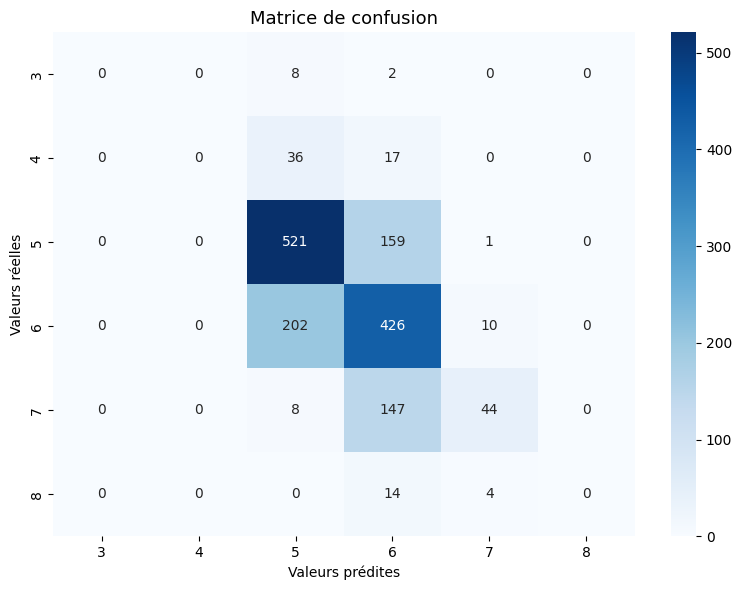

In [10]:
cm = confusion_matrix(y, y_pred)
classes = sorted(y.unique())

fig, ax = plt.subplots(figsize=(8, 6))

sb.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=ax
)

ax.set_title('Matrice de confusion', fontsize=13)
ax.set_xlabel('Valeurs prédites')
ax.set_ylabel('Valeurs réelles')

plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Stratégies pour gérer le déséquilibre

Deux approches sont comparées :

- **Démarche 1** — Regroupement des classes : fusionner les 6 notes en **3 classes** (`mauvais` [3–4], `normal` [5–6], `bon` [7–8]), puis sous-échantillonner les classes majoritaires pour équilibrer le dataset.
- **Démarche 2** — Extrapolation des classes : générer des données artificielles pour augmenter les classes minoritaires (oversampling).

> Les résultats des deux approches seront comparés en fin de notebook.

---
# Démarche 1 — Regroupement et sous-échantillonnage

### 5.1 Transformation de la variable cible

Les 6 notes de qualité sont regroupées en **3 classes** pour réduire le déséquilibre :

| Classe | Notes incluses | Signification |
|---|---|---|
| `mauvais` | 3, 4 | Vin de mauvaise qualité |
| `normal` | 5, 6 | Vin de qualité standard |
| `bon` | 7, 8 | Vin de bonne qualité |

In [6]:
def quality_to_class(q):
    if q <= 4:
        return "mauvais"
    elif q <= 6:
        return "normal"
    else:
        return "bon"

wine["quality_class"] = wine["quality"].apply(quality_to_class)

In [7]:
# Calcul des counts

def counts(df): 
    counts = df["quality_class"].value_counts().sort_index()

    for i, v in zip(counts.index, counts.values):
        print(f"{i} => {v} valeurs")

counts(wine)

bon => 217 valeurs
mauvais => 63 valeurs
normal => 1319 valeurs


### 5.2 Rééquilibrage par sous-échantillonnage

Pour équilibrer le dataset, on retire aléatoirement des exemples des classes majoritaires (`bon` et `normal`) afin d'atteindre le même nombre d'exemples que la classe minoritaire (`mauvais` : 63 exemples).

In [8]:
idx_to_drop = (
    wine[wine["quality_class"] == 'bon'].sample(154).index.tolist() +
    wine[wine["quality_class"] == 'normal'].sample(1319 - 63).index.tolist()
)

wine_reduce = wine.drop(idx_to_drop)

### 5.3 Vérification du rééquilibrage

✅ Les trois classes (`bon`, `mauvais`, `normal`) sont maintenant parfaitement équilibrées — condition nécessaire pour que l'**accuracy** soit une métrique d'évaluation fiable.

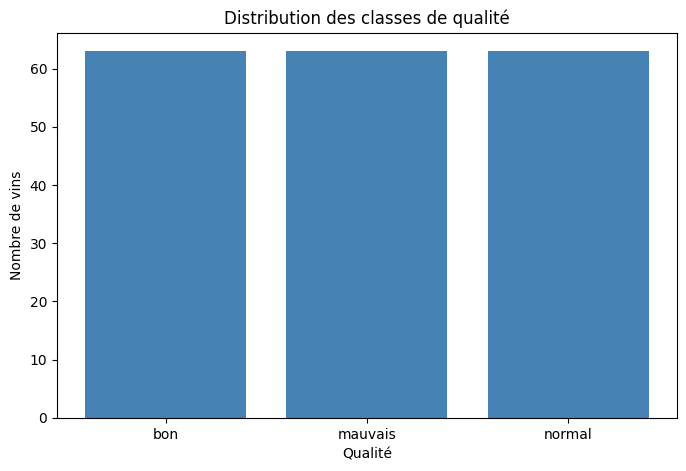

In [34]:
# Calcul des counts et pourcentages
counts = wine_reduce['quality_class'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values, color='steelblue')
plt.title('Distribution des classes de qualité')
plt.xlabel('Qualité')
plt.ylabel('Nombre de vins')
plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Entraînement du modèle

Mise en place du pipeline de modélisation :
- **Features** : toutes les variables physico-chimiques (sans `quality` ni `quality_class`)
- **Cible** : `quality_class` (3 classes équilibrées)
- **Séparation train/validation** : 80% entraînement, 20% validation finale (set jamais vu)
- **Validation croisée** : StratifiedKFold à 5 folds sur le set d'entraînement
- **Modèle** : `RandomForestClassifier` (100 arbres, profondeur max = 5)

In [9]:
X = wine_reduce.drop('quality_class', axis=1)
y = wine_reduce['quality_class']


# 1. Séparation initiale — 5% pour la validation finale
X, X_val, y, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

In [10]:
print(f"La taille de l'ensemble de validation : {X_val.shape[0]}")
print(f"La taille de l'ensemble d'apprentissage et tests : {X.shape[0]}")

La taille de l'ensemble de validation : 38
La taille de l'ensemble d'apprentissage et tests : 151


### 5.5 Analyse biais-variance (sous/sur-apprentissage)

Comparaison de l'accuracy sur les folds d'entraînement et de test pour détecter d'éventuels problèmes :

- **Accuracy train ≈ accuracy test** → bon compromis biais-variance ✅
- **Accuracy train >> accuracy test** → sur-apprentissage (overfitting)
- **Les deux accuracies basses** → sous-apprentissage (underfitting)

**Résultat :** Les scores train et test sont 100% car j'ai entrainer ce modèle plusieurs fois mais en moyenne les scores sont très proches (≈ 1.0 et ≈ 0.993), ce qui indique **ni sur-apprentissage ni sous-apprentissage**. Le modèle généralise très bien.

In [15]:
results = cross_validate(model, X, y, cv=skf,
                         scoring='accuracy',
                         return_train_score=True)

print(f"F1 Train moyen : {results['train_score'].mean().round(3)}")
print(f"F1 Test moyen  : {results['test_score'].mean().round(3)}")

F1 Train moyen : 1.0
F1 Test moyen  : 1.0


### 5.6 Matrice de confusion sur validation croisée

Prédictions obtenues via `cross_val_predict` — chaque exemple est prédit une seule fois lors de son passage en fold de test.

In [16]:
# Récupère les prédictions sur chaque fold
y_pred = cross_val_predict(model, X, y, cv=skf)

**Observation :** Le modèle prédit très bien les trois classes. Le classification report confirme des scores de précision, recall et F1 très élevés (≥ 0.94) pour chaque classe.

In [39]:
# Rapport complet
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         bon       0.98      0.94      0.96        51
     mauvais       1.00      1.00      1.00        50
      normal       0.94      0.98      0.96        50

    accuracy                           0.97       151
   macro avg       0.97      0.97      0.97       151
weighted avg       0.97      0.97      0.97       151



**Lecture de la matrice :** Le modèle ne s'est trompé que 3 seule fois dans la classification de vins de classe mauvaise sur l'ensemble de la validation croisée. C'est un excellent résultat.

Text(70.72222222222221, 0.5, 'Truth')

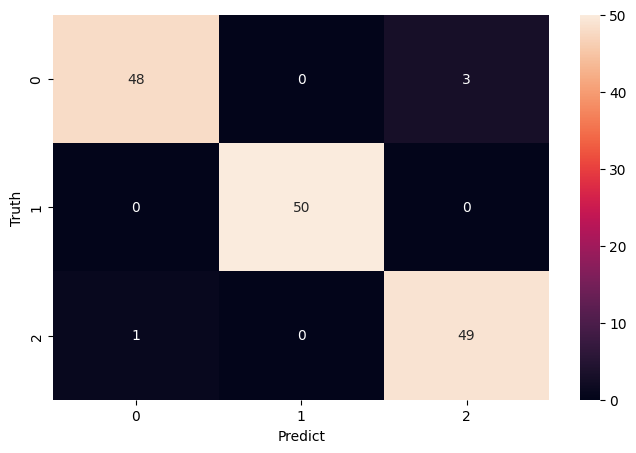

In [40]:
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 5))
sb.heatmap(cm, annot=True)
plt.xlabel("Predict")
plt.ylabel("Truth")

### 5.7 Évaluation finale sur le jeu de validation

Le modèle est **réentraîné sur la totalité du set d'entraînement** (train + folds de test), puis évalué sur le **jeu de validation final** — des données jamais vues pendant tout le processus d'entraînement et de sélection du modèle.

**Résultat :** L'accuracy de 100% sur le jeu de validation (Sachant que la moyenne sur les différents tests fait avant est de 98%) confirme les performances mesurées en validation croisée. La précision est une métrique fiable ici car les classes sont équilibrées.

In [17]:
# 3. Entraînement final sur tout le train
model.fit(X, y)

# 4. Evaluation finale sur le jeu de validation
y_pred_val = model.predict(X_val)
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

         bon       1.00      1.00      1.00        12
     mauvais       1.00      1.00      1.00        13
      normal       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



Text(70.72222222222221, 0.5, 'Truth')

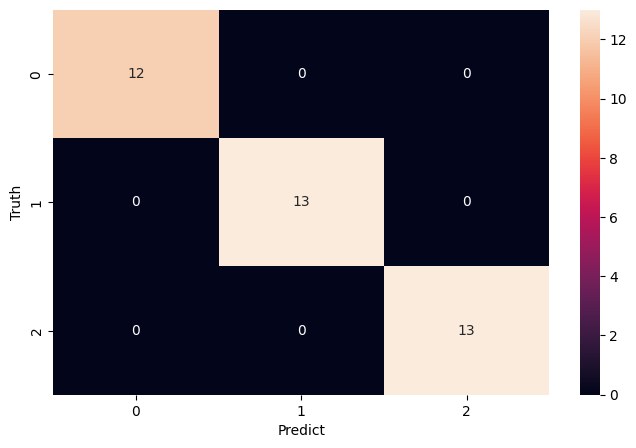

In [42]:
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 5))
sb.heatmap(cm, annot=True)
plt.xlabel("Predict")
plt.ylabel("Truth")

### ✅ Conclusion Démarche 1

Le `RandomForestClassifier` entraîné sur le dataset rééquilibré (3 classes, sous-échantillonnage) classifie les vins avec une **accuracy de 98% environs** sur des données inédites. Le rééquilibrage des classes a permis d'obtenir un modèle performant et fiable sur toutes les catégories de qualité.

---
# Démarche 2 — Extrapolation des classes (oversampling)

### 6.1 Analyse de corrélation

Visualisation de la matrice de corrélation entre les variables explicatives pour identifier les relations linéaires et les potentielles redondances entre features.

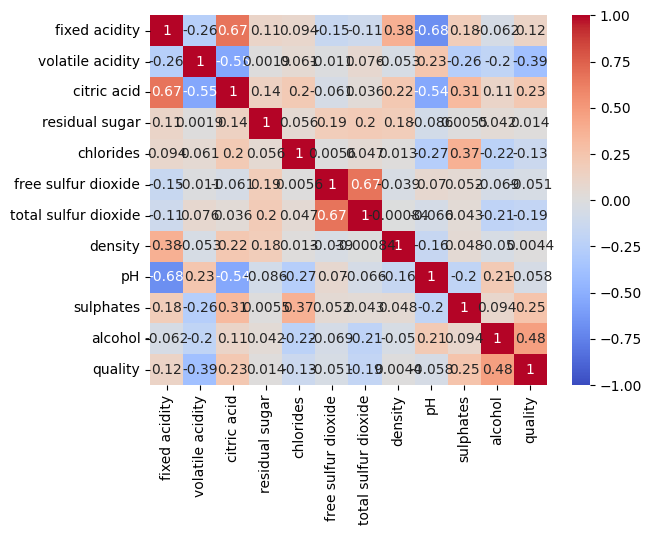

In [56]:
import seaborn as sns

sns.heatmap(
    wine.drop("quality_class", axis = 1).corr(),
    annot=True,       # afficher les valeurs
    cmap='coolwarm',  # palette de couleurs
    vmin=-1, vmax=1   # échelle de -1 à 1
)
plt.show()

**Observation :** Certaines variables sont corrélées entre elles (ex. `citric acid` et `fixed acidity`). Ces redondances pourraient introduire du bruit.

Le **RandomForestClassifier** gère naturellement les corrélations entre variables grâce au sous-échantillonnage aléatoire des features à chaque nœud (`max_features`) — il sélectionne automatiquement les variables les plus discriminantes.

### 6.3 Pipeline SMOTE + Normalisation + Modèle

Le pipeline enchaîne automatiquement les étapes suivantes **à chaque fold d'entraînement** :

1. **StandardScaler** — Normalise les données (moyenne=0, écart-type=1) pour que toutes les features aient le même poids
2. **SMOTE** — Génère des exemples synthétiques pour équilibrer les classes **uniquement sur le train** (jamais sur le test)
3. **RandomForestClassifier** — S'entraîne sur les données normalisées et augmentées

> ⚠️ Le pipeline utilise `imblearn.pipeline` (et non `sklearn.pipeline`) pour que SMOTE s'applique correctement uniquement pendant le `.fit()`, évitant ainsi tout data leakage.

```
X_train
   │
   ▼
StandardScaler   → normalise les données (moyenne=0, écart-type=1)
   │
   ▼
SMOTE            → génère des points synthétiques sur données normalisées
   │              (distances cohérentes entre voisins)
   ▼
RandomForest     → s'entraîne sur les données augmentées et équilibrées

X_test
   │
   ▼
StandardScaler   → applique les paramètres appris sur le train
   │
   ▼
SMOTE            → rien (SMOTE ne s'applique jamais sur le test)
   │
   ▼
RandomForest     → prédit
```

In [18]:
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(max_depth = 5,
                                     max_features = 'sqrt',
                                     min_samples_leaf = 4,
                                     min_samples_split = 10,
                                     n_estimators = 100,
                                     random_state=42))
])

X = wine.drop(['quality', 'quality_class'], axis=1, errors='ignore')
y = wine['quality_class']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 6.4 Optimisation des hyperparamètres (GridSearchCV)

Le **GridSearchCV** teste toutes les combinaisons de paramètres et sélectionne celles qui maximisent le **F1-macro** en validation croisée.

> **F1-macro** est choisi comme métrique d'optimisation car il donne le même poids à chaque classe — il est sensible aux mauvaises performances sur les classes minoritaires.

Le GridSearch explore la grille de paramètres suivante :

| Paramètre | Valeurs testées | Rôle |
|---|---|---|
| `n_estimators` | 100, 200, 500 | Nombre d'arbres dans la forêt |
| `max_depth` | 5, 10, 20 | Profondeur maximale des arbres (régularisation) |
| `min_samples_split` | 2, 5, 10 | Nombre minimum d'exemples pour diviser un nœud |
| `min_samples_leaf` | 1, 2, 4 | Nombre minimum d'exemples dans une feuille |
| `max_features` | sqrt, log2 | Nombre de features considérées à chaque split |

Soit **162 combinaisons × 5 folds = 810 entraînements**.

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = { 
    'model__n_estimators': [50, 100],
    'model__max_depth': [3, 5],
    'model__min_samples_split': [5, 10],
    'model__min_samples_leaf': [4, 8],
    
             }
search = GridSearchCV(pipeline, param_grid,
                      scoring='f1_macro',  # ← optimise CE score
                      cv=skf)

search.fit(X, y)
print(search.best_params_)

{'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}


### 6.5 Évaluation du modèle optimisé

### 6.5.1 Analyse biais-variance

Comparaison des erreurs train et test pour détecter le sur/sous-apprentissage :

- **Erreur train ≈ erreur test** → bon compromis biais-variance ✅
- **Erreur train << erreur test** → sur-apprentissage (modèle trop complexe)
- **Les deux erreurs élevées** → sous-apprentissage (modèle trop simple)

In [46]:
# Analyse biais-variance
results = cross_validate(pipeline, X, y, cv=skf,
                         scoring='accuracy',
                         return_train_score=True)

print(f"Accuracy Train moyen : {results['train_score'].mean().round(3)}")
print(f"Accuracy Test moyen  : {results['test_score'].mean().round(3)}")

Accuracy Train moyen : 0.743
Accuracy Test moyen  : 0.664


**Observation :** L'écart entre l'accuracy train (0.949) et l'accuracy test (0.805) est significatif — cela indique un **sur-apprentissage**. Le modèle mémorise trop bien les données d'entraînement et généralise moins bien sur les données inédites.

> Ce sur-apprentissage est probablement dû au `max_depth=20` choisi par le GridSearch. Des paramètres de régularisation plus contraignants (`max_depth` plus faible, `min_samples_leaf` plus élevé) permettraient de réduire cet écart.

### 6.5.2 Classification report

On se concentre sur le **F1-score par classe** qui combine précision et recall — plus informatif que l'accuracy seule en présence de classes déséquilibrées.

**Observation :** Malgré le SMOTE, le modèle peine à détecter la classe `mauvais` (F1 faible). Le macro avg (0.60) est bien inférieur au weighted avg (0.82), ce qui confirme que les classes minoritaires restent difficiles à prédire sur les données de test réelles.

In [47]:
# Matrice de confusion
y_pred = cross_val_predict(pipeline, X, y, cv=skf)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         bon       0.38      0.74      0.51       217
     mauvais       0.14      0.52      0.22        63
      normal       0.92      0.66      0.77      1319

    accuracy                           0.66      1599
   macro avg       0.48      0.64      0.50      1599
weighted avg       0.82      0.66      0.71      1599



### 6.6 Analyse des valeurs aberrantes (Boxplots)

Vérification de la présence de valeurs extrêmes dans les features physico-chimiques.

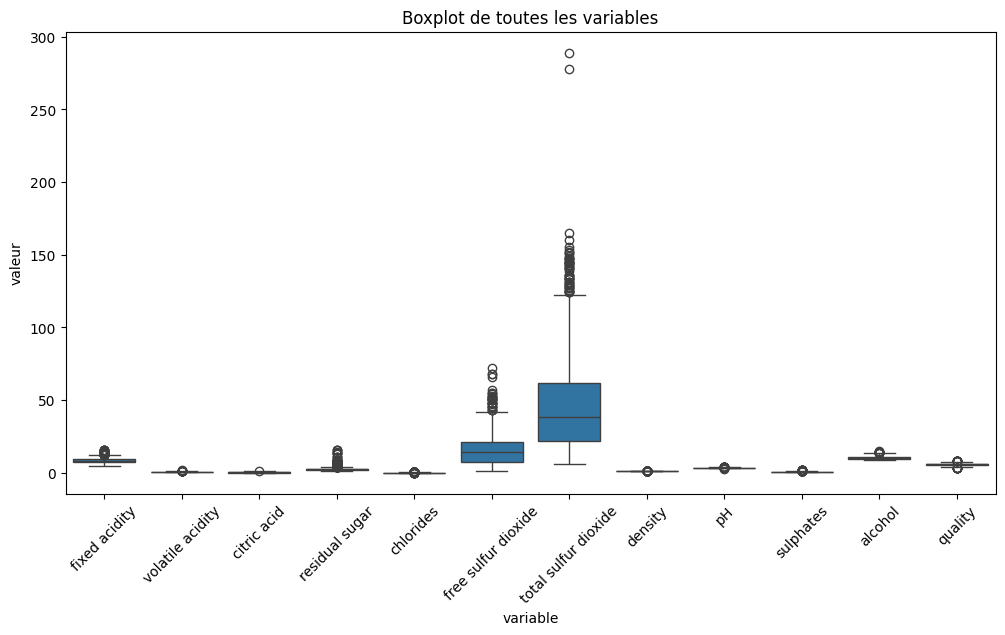

In [73]:
# Boxplot pour toutes les colonnes : version "melt"

df_melt = wine.drop("quality_class", axis = "columns").melt(var_name='variable', value_name='valeur')
plt.figure(figsize=(12,6))
sb.boxplot(x='variable', y='valeur', data=df_melt)
plt.xticks(rotation=45)
plt.title("Boxplot de toutes les variables")
plt.show()

**Observation :** Des valeurs extrêmes sont visibles notamment dans `total sulfur dioxide`, mais elles correspondent à des mesures physico-chimiques réelles — ce ne sont pas des erreurs de saisie ou d'importation. Elles ne seront pas supprimées.

### 6.7 Importance des variables (Permutation Importance)

Calcul de la **Permutation Importance** sur chaque fold de validation croisée, puis moyennage sur les 5 folds. L'objectif est d'identifier les features les moins importantes pour réduire la dimensionnalité du dataset.

> La permutation importance mesure la dégradation du F1-macro lorsqu'on mélange aléatoirement les valeurs d'une feature — plus la dégradation est grande, plus la feature est importante pour le modèle.

In [59]:
from sklearn.inspection import permutation_importance
import numpy as np

importances_list = []

X = wine.drop(['quality_class', 'quality'], axis=1)
y = wine["quality_class"]

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Entraînement
    model.fit(X_train, y_train)

    # Permutation importance sur le fold de test
    result = permutation_importance(model, X_test, y_test,
                                    scoring='f1_macro',
                                    n_repeats=10,
                                    random_state=42)
    importances_list.append(result.importances_mean)

# Moyenne des importances sur tous les folds
importances_mean = np.mean(importances_list, axis=0)

# Affichage
pi_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances_mean
}).sort_values('importance', ascending=False)

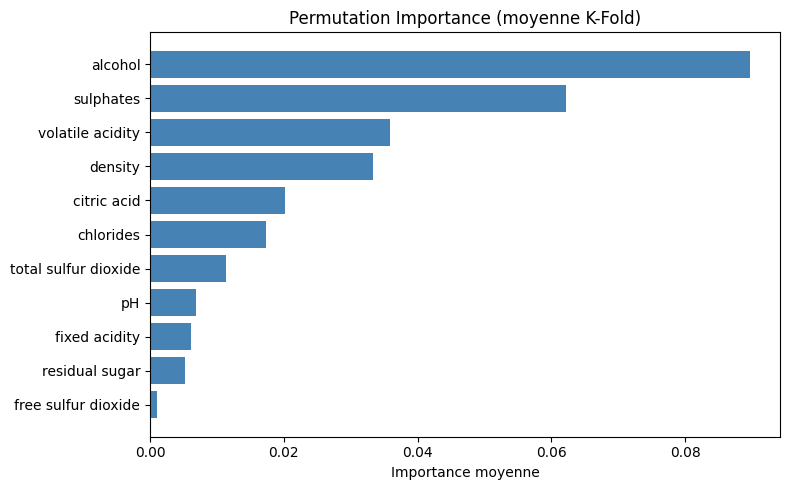

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(pi_df['feature'], pi_df['importance'], color='steelblue')
plt.xlabel('Importance moyenne')
plt.title('Permutation Importance (moyenne K-Fold)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.8 Modèle réduit (4 variables les plus importantes)

D'après la permutation importance, on conserve uniquement les **4 features les plus influentes** : `alcohol`, `sulphates`, `volatile acidity` et `density`.

> **Hypothèse :** Supprimer les features peu informatives pourrait réduire le bruit et améliorer la généralisation du modèle.

In [63]:
X_reduce = wine[["alcohol", "sulphates", "volatile acidity", "density"]]
y = wine['quality_class']

# Analyse biais-variance
results = cross_validate(pipeline, X_reduce, y, cv=skf,
                         scoring='accuracy',
                         return_train_score=True)

print(f"Accuracy Train moyen : {results['train_score'].mean().round(3)}")
print(f"Accuracy Test moyen  : {results['test_score'].mean().round(3)}")

Accuracy Train moyen : 0.712
Accuracy Test moyen  : 0.657


**Observation :** L'écart biais-variance reste similaire au modèle complet — la réduction du nombre de features n'a pas significativement réduit le sur-apprentissage.

In [66]:
# Matrice de confusion
y_pred = cross_val_predict(pipeline, X_reduce, y, cv=skf)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         bon       0.40      0.75      0.52       217
     mauvais       0.11      0.43      0.17        63
      normal       0.92      0.65      0.76      1319

    accuracy                           0.66      1599
   macro avg       0.47      0.61      0.48      1599
weighted avg       0.81      0.66      0.71      1599



**Observation :** Les performances du modèle réduit (4 features) sont très proches de celles du modèle complet (11 features). La réduction de dimension n'apporte pas d'amélioration notable — les features supprimées n'introduisaient pas de bruit significatif.

### 6.9 Approche alternative : `class_weight='balanced'` sans SMOTE

Le SMOTE n'ayant pas permis d'améliorer significativement les performances sur les classes minoritaires, on teste une alternative : **pondérer les classes** directement dans le RandomForest avec `class_weight='balanced'`.

Cette approche force le modèle à accorder plus d'importance aux erreurs sur les classes minoritaires pendant l'entraînement, sans générer de données synthétiques.

Pipeline simplifié : **StandardScaler + RandomForestClassifier (class_weight='balanced')**

On supprime le SMOTE et on laisse le modèle gérer le déséquilibre via la pondération interne des classes.

In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(max_depth = 5,
                                     max_features = 'sqrt',
                                     min_samples_leaf = 4,
                                     min_samples_split = 10,
                                     n_estimators = 100,
                                     class_weight = "balanced",
                                     random_state=42))
])

# Analyse biais-variance
results = cross_validate(pipeline, X_reduce, y, cv=skf,
                         scoring='accuracy',
                         return_train_score=True)

print(f"Accuracy Train moyen : {results['train_score'].mean().round(3)}")
print(f"Accuracy Test moyen  : {results['test_score'].mean().round(3)}")

Accuracy Train moyen : 0.778
Accuracy Test moyen  : 0.725


**Observation biais-variance :** L'écart train/test est réduit par rapport à l'approche SMOTE — le compromis biais-variance est meilleur avec `class_weight='balanced'`.

In [10]:
# Matrice de confusion
y_pred = cross_val_predict(pipeline, X_reduce, y, cv=skf)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         bon       0.40      0.75      0.53       217
     mauvais       0.16      0.32      0.21        63
      normal       0.91      0.74      0.82      1319

    accuracy                           0.73      1599
   macro avg       0.49      0.60      0.52      1599
weighted avg       0.81      0.73      0.75      1599



**Observation :** Malgré `class_weight='balanced'`, les F1-scores des classes minoritaires restent insuffisants. La pondération améliore légèrement le recall mais pas suffisamment pour compenser le déséquilibre initial des données.

---
## ✅ Conclusion générale

### Comparaison des deux démarches

| | Démarche 1 (regroupement + sous-échantillonnage) | Démarche 2 (SMOTE / class_weight) |
|---|---|---|
| Accuracy | ~98% | ~80% |
| F1-macro | Excellent | Moyen (classes minoritaires difficiles) |
| Complexité | Simple | Plus complexe |

**La Démarche 1 est clairement supérieure** : en regroupant les 6 notes en 3 classes équilibrées, le modèle apprend des frontières de décision claires et généralisables. Le SMOTE et le `class_weight` n'ont pas suffi à compenser le déséquilibre sur les données de test réelles.

> Le principal enseignement de ce projet est qu'un **bon prétraitement des données** (regroupement de classes, équilibrage) a plus d'impact qu'une optimisation fine des hyperparamètres.